In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
words = open('names (1).txt','r').read().splitlines() 
words

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett',
 'victoria',
 'madison',
 'luna',
 'grace',
 'chloe',
 'penelope',
 'layla',
 'riley',
 'zoey',
 'nora',
 'lily',
 'eleanor',
 'hannah',
 'lillian',
 'addison',
 'aubrey',
 'ellie',
 'stella',
 'natalie',
 'zoe',
 'leah',
 'hazel',
 'violet',
 'aurora',
 'savannah',
 'audrey',
 'brooklyn',
 'bella',
 'claire',
 'skylar',
 'lucy',
 'paisley',
 'everly',
 'anna',
 'caroline',
 'nova',
 'genesis',
 'emilia',
 'kennedy',
 'samantha',
 'maya',
 'willow',
 'kinsley',
 'naomi',
 'aaliyah',
 'elena',
 'sarah',
 'ariana',
 'allison',
 'gabriella',
 'alice',
 'madelyn',
 'cora',
 'ruby',
 'eva',
 'serenity',
 'autumn',
 'adeline',
 'hailey',
 'gianna',
 'valentina',
 'isla',
 'eliana',
 'quinn',
 'nevaeh',
 'ivy',
 'sadie',
 'piper',
 'lydia',
 'alexa',
 'josephine',
 'emery',
 'julia'

In [3]:
chars= sorted(list(set(''.join(words))))
mapping  = {c : i+1  for i,c in enumerate(chars)}
mapping['.'] = 0
reverse_mapping = {i:c for c,i in mapping.items()}
vocab_size = len(reverse_mapping)
print(reverse_mapping)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
import random
block_size = 3
def Build_dataset(words):
    
    X , y = [] , []
    for w in words:
        #print(w)
        context = [0]*block_size
        for ch in w + '.':
            ix = mapping[ch]
            X.append(context)
            y.append(ix)
            #print(''.join(reverse_mapping[i] for i in context) ,'---->' , reverse_mapping[ix])
            context = context[1:] + [ix]
        
    X=torch.tensor(X)
    y=torch.tensor(y)
    return X ,y

random.seed(42)
random.shuffle(words)
n1 =int(0.8*len(words))
n2 =int(0.9*len(words))

Xtr , ytr = Build_dataset(words[:n1])
Xdv , ydv = Build_dataset(words[n1:n2])
Xts , yts = Build_dataset(words[n2:])

In [5]:
n_embd = 10
n_hidden = 200


g=torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1= torch.randn((n_embd * block_size, n_hidden), generator=g) *(5/3)/((n_embd * block_size)**0.5)
b1 = torch.rand(n_hidden , generator=g) *0.01
W2 = torch.randn((n_hidden , vocab_size) , generator=g) * 0.01
b2 = torch.randn(vocab_size , generator=g) * 0 

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))

parameters = [C,W1,b1,W2,b2 , bngain , bnbias]

print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12297


In [6]:
max_steps = 200000
lossi = []
batch_size = 32

for i in range(max_steps):
    #minibatch
    ix = torch.randint(0 , Xtr.shape[0] , (batch_size,  ), generator=g)
    xb = Xtr[ix]
    yb = ytr[ix]

    #forward pass 
    emb = C[xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0 , keepdim=True)) / hpreact.std(0 , keepdim=True) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2  + b2
    loss =F.cross_entropy(logits , yb)
    
    #backward pass 
    for p in parameters:
        p.grad= None
    loss.backward()

    #update 
    lr = 0.1 if i < 10000 else 0.01 
    for p in parameters:
        p.data += - lr* p.grad
    # lri.append(lre[i])
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.log10().item())



      0/200000: 3.2906
  10000/200000: 1.9757
  20000/200000: 1.8456
  30000/200000: 2.0796
  40000/200000: 2.2380
  50000/200000: 2.4394
  60000/200000: 2.0148
  70000/200000: 1.7101
  80000/200000: 2.2012
  90000/200000: 2.1473
 100000/200000: 2.1367
 110000/200000: 2.4159
 120000/200000: 1.7462
 130000/200000: 2.2031
 140000/200000: 2.1800
 150000/200000: 2.2209
 160000/200000: 2.2265
 170000/200000: 1.6162
 180000/200000: 1.9122
 190000/200000: 2.0573


In [12]:
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    
    bnmean = hpreact.mean(0 , keepdim=True)
    bnstd = hpreact.std(0 , keepdim=True)

In [13]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr , ytr),
        'val': (Xdv , ydv),
        'test': (Xts , yts)
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2  + b2
    loss =F.cross_entropy(logits , y)
    print(split, loss.item())
split_loss('train')
split_loss('val')


train 2.112222194671631
val 2.1389992237091064


tensor(-0.0119) tensor(0.9972)
tensor(-0.0003) tensor(1.0017)


(array([2.13708933e-05, 4.27417865e-05, 2.13708933e-05, 6.41126798e-05,
        1.06854466e-04, 8.54835731e-05, 2.77821613e-04, 4.70159652e-04,
        8.54835731e-04, 1.45322074e-03, 2.09434754e-03, 4.40240401e-03,
        6.28304262e-03, 1.05785922e-02, 1.84858227e-02, 2.73120016e-02,
        4.21220306e-02, 6.38989709e-02, 9.57202310e-02, 1.38141454e-01,
        1.89025551e-01, 2.51193479e-01, 3.21076300e-01, 3.73563214e-01,
        4.12372757e-01, 4.25344889e-01, 4.09573170e-01, 3.66040660e-01,
        3.06757802e-01, 2.42046737e-01, 1.79942921e-01, 1.26643914e-01,
        9.29206439e-02, 6.11421256e-02, 3.88095422e-02, 2.53031376e-02,
        1.63487334e-02, 8.78343713e-03, 6.00522101e-03, 3.56893918e-03,
        2.22257290e-03, 9.40319304e-04, 9.61690197e-04, 5.55643225e-04,
        2.56450719e-04, 1.49596253e-04, 4.27417865e-05, 8.54835731e-05,
        4.27417865e-05, 2.13708933e-05]),
 array([-5.94659805, -5.71263497, -5.47867189, -5.24470881, -5.01074574,
        -4.77678266, 

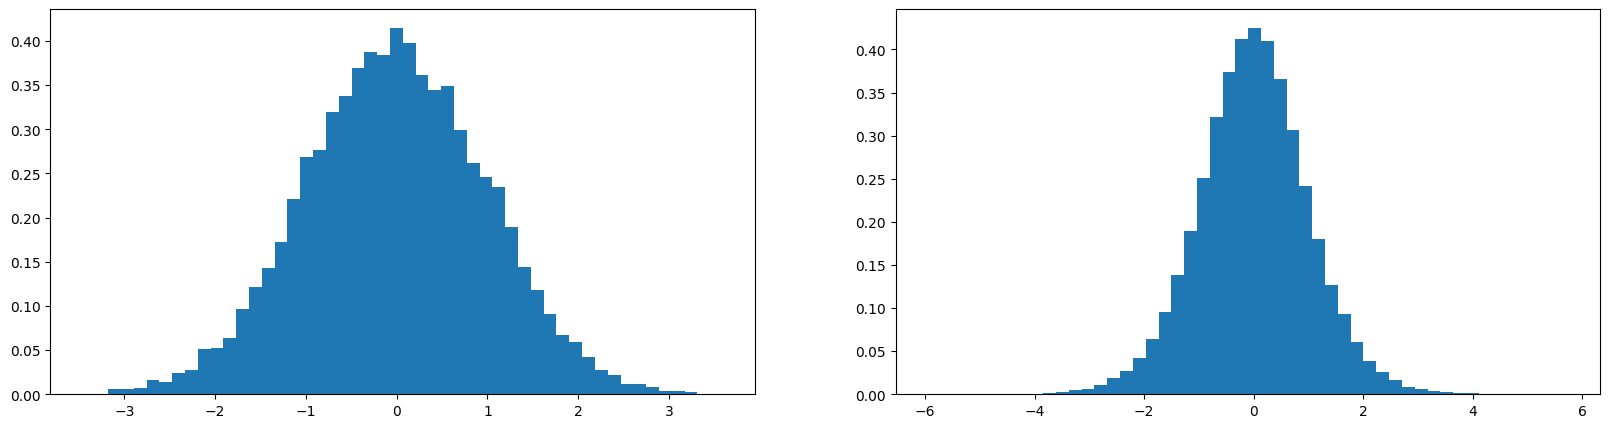

In [ ]:
x = torch.randn(1000 , 10)
y = torch.randn(10 , 200) / 10 ** 0.5
y = x @ y
print(x.mean() , x.std())
print(y.mean() , y.std())
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.hist(x.view(-1).tolist(), 50 , density=True)
plt.subplot(1,2,2)
plt.hist(y.view(-1).tolist(), 50 , density=True)


In [8]:
hpreact.shape

torch.Size([32, 200])

In [9]:
hpreact.mean(0 , keepdim=True).shape
hpreact.std(0 , keepdim=True).shape

torch.Size([1, 200])